In [1]:
%reload_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import py4DSTEM
from scipy.stats import ks_2samp
from matplotlib.ticker import ScalarFormatter
from scipy.stats import gaussian_kde
import numpy as np
import pickle
from microstructure_inference.dataProcessing import read_4D, align, make_orientation_map_based_on_4D_rotation_matrices
import torch
import os
from microstructure_inference.analysis.measure_correlation_score import radial_average_corrMap, zone_axis_cross_correlation_map_masked, zone_axis_autocorrelation_map_masked, zone_axis_local_correlation_map

print(py4DSTEM.__version__)
%autoreload 2

0.14.8


In [2]:
def based_on_orientation_prediction_return_zone_axis_map(table_BPs_scanIndex,scan_x_dim,scan_y_dim,prediced_rotation_matrices):

    rotation_map_4D_transformer = np.zeros((scan_x_dim,scan_y_dim,3,3))

    for key, value in table_BPs_scanIndex.items():
        
    
        i, j = value['scanIndices'][0], value['scanIndices'][1]
        
        rotation_map_4D_transformer[i,j] = prediced_rotation_matrices[key]
    
    orientation_map_transformer = make_orientation_map_based_on_4D_rotation_matrices(rotation_map_4D_transformer, crystal)

    zone_axis_map_transformer = np.zeros((scan_x_dim,scan_y_dim,3))
    symmReduced_x_axis_map_transformer = np.zeros((scan_x_dim,scan_y_dim,3))
    
    for key, value in table_BPs_scanIndex.items():
        
    
        i, j = value['scanIndices'][0], value['scanIndices'][1]
        
        zone_axis_map_transformer[i,j] = orientation_map_transformer.family[i,j][0][:,2]
        symmReduced_x_axis_map_transformer[i,j] = orientation_map_transformer.family[i,j][0][:,0]


    return zone_axis_map_transformer


def return_angle_in_radian_between_two_vectors(vec_1, vec_2):

    if np.linalg.norm(vec_1) < 1e-12 or np.linalg.norm(vec_2) < 1e-12:
        raise ValueError("Angle is undefined for zero-length vectors")

    vec_1_normalized = vec_1 / np.linalg.norm(vec_1)
    vec_2_normalized = vec_2 / np.linalg.norm(vec_2)

    vec_1_2_dot_product = np.dot(vec_1_normalized, vec_2_normalized)

    vec_1_2_dot_product = np.clip(vec_1_2_dot_product, -1., 1.)

    return np.arccos(vec_1_2_dot_product)

In [3]:
correlationThresholdTemplateMatch = int(14000)

In [4]:

pixel_size = 0.0328
# pixel_size = 0.03158073
sigma_compare = 0.02
pixel_numbers = 128

k_max = pixel_size * pixel_numbers / 2.
accelerating_voltage = int(300e3)


script_path = os.getcwd() + "/"
processed_data_saving_path = script_path + "processed_data/"
fig05_panel_a_c_path = script_path + "figure_05_panel_a_c/"
fig05_panel_d_f_path = script_path + "figure_05_panel_d_f/"
file_path = script_path

processed_path_1 = script_path + "independently_trained_model_1/processed_data/"
processed_path_2 = script_path + "independently_trained_model_2/processed_data/"
processed_path_3 = script_path + "independently_trained_model_3/processed_data/"
processed_path_4 = script_path + "independently_trained_model_4/processed_data/"
processed_path_5 = script_path + "independently_trained_model_5/processed_data/"
processed_path_6 = script_path + "independently_trained_model_6/processed_data/"


In [5]:


Bragg_vector_file_name = "bragg_disks_corThForK80000_dog_sig1_2.00_sig2_6.00_cortThForTemp_%d"%(correlationThresholdTemplateMatch)
filepath_braggdisks_cal = file_path + Bragg_vector_file_name + ".h5"
bragg_peaks = py4DSTEM.read(filepath_braggdisks_cal)

scan_x_dim = bragg_peaks.shape[0]
scan_y_dim = bragg_peaks.shape[1]


file_str_after_preprocessing_1 = "sing_01" + "_" + Bragg_vector_file_name
prediced_rotation_matrices_1 = np.load(processed_path_1 + file_str_after_preprocessing_1 + "_rotation_matrices_canonical.npy")
print("file_str_after_preprocessing_1", file_str_after_preprocessing_1)

file_str_after_preprocessing_2 = "sing_02" + "_" + Bragg_vector_file_name
prediced_rotation_matrices_2 = np.load(processed_path_2 + file_str_after_preprocessing_2 + "_rotation_matrices_canonical.npy")
print("file_str_after_preprocessing_2", file_str_after_preprocessing_2)

file_str_after_preprocessing_3 = "sing_03" + "_" + Bragg_vector_file_name
prediced_rotation_matrices_3 = np.load(processed_path_3 + file_str_after_preprocessing_3 + "_rotation_matrices_canonical.npy")
print("file_str_after_preprocessing_3", file_str_after_preprocessing_3)

file_str_after_preprocessing_4 = "sing_04" + "_" + Bragg_vector_file_name
prediced_rotation_matrices_4 = np.load(processed_path_4 + file_str_after_preprocessing_4 + "_rotation_matrices_canonical.npy")
print("file_str_after_preprocessing_4", file_str_after_preprocessing_4)

file_str_after_preprocessing_5 = "sing_05" + "_" + Bragg_vector_file_name
prediced_rotation_matrices_5 = np.load(processed_path_5 + file_str_after_preprocessing_5 + "_rotation_matrices_canonical.npy")
print("file_str_after_preprocessing_5", file_str_after_preprocessing_5)

file_str_after_preprocessing_6 = "sing_06" + "_" + Bragg_vector_file_name
prediced_rotation_matrices_6 = np.load(processed_path_6 + file_str_after_preprocessing_6 + "_rotation_matrices_canonical.npy")
print("file_str_after_preprocessing_6", file_str_after_preprocessing_6)



DP_2D_indices_in_scan_space = []
intensities = []

table_BPs_scanIndex = {}
dict_idx = 0
for i in range(bragg_peaks.shape[0]):
    for j in range(bragg_peaks.shape[1]):
        if len(bragg_peaks.cal[i,j].qx) > 2:

            qx = np.copy(bragg_peaks.cal[i,j].data["qx"])
            qy = np.copy(bragg_peaks.cal[i,j].data["qy"])
            intensity = np.copy(bragg_peaks.cal[i,j].data["intensity"] / np.max(bragg_peaks.cal[i,j].data["intensity"]))

            k_radial_distnaces_of_BPs = np.linalg.norm(np.stack((qx, qy)).T, axis = 1)
            index_of_direct_beam = np.argmin(k_radial_distnaces_of_BPs)

            qx = np.delete(qx, index_of_direct_beam)
            qy = np.delete(qy, index_of_direct_beam)
            intensity = np.delete(intensity, index_of_direct_beam)

            

            positions_of_Bragg_disks = np.stack((qx, qy)).T
            k_radial_distnaces_of_BPs = np.linalg.norm(positions_of_Bragg_disks, axis = 1)
            polar_angles = np.arctan2(positions_of_Bragg_disks[:,1], positions_of_Bragg_disks[:,0])


            table_BPs_scanIndex[dict_idx] = {'input': np.stack((k_radial_distnaces_of_BPs, polar_angles, intensity)).T, 'scanIndices': [i,j]}

            dict_idx += 1
            
# torch_input = torch.load(processed_data_saving_path + file_str_after_preprocessing + "_table.pt")


crystal = py4DSTEM.process.diffraction.Crystal.from_CIF(file_path + "Cu_fcc.cif")
crystal.setup_diffraction(accelerating_voltage)
crystal.calculate_structure_factors(
    k_max,
)

# # Create an orientation plan for [0001] WS2
# crystal.orientation_plan(
#     angle_step_zone_axis = 1,
#     angle_step_in_plane = 1,
#     accel_voltage = 300e3,
#     corr_kernel_size= 0.08, # was 0.08 before 0.12 not bad
#     zone_axis_range='auto',
# )

# Create an orientation plan for [0001] WS2
crystal.orientation_plan(
    angle_step_zone_axis = 2,
    angle_step_in_plane = 2,
    accel_voltage = accelerating_voltage,
    # intensity_power = 0.5,
    # corr_kernel_size= 0.08, # was 0.08 before 0.12 not bad
    zone_axis_range='auto',
)


Reading PointListArray: 100%|███| 38400/38400 [00:02<00:00, 16381.73PointList/s]


file_str_after_preprocessing_1 sing_01_bragg_disks_corThForK80000_dog_sig1_2.00_sig2_6.00_cortThForTemp_14000
file_str_after_preprocessing_2 sing_02_bragg_disks_corThForK80000_dog_sig1_2.00_sig2_6.00_cortThForTemp_14000
file_str_after_preprocessing_3 sing_03_bragg_disks_corThForK80000_dog_sig1_2.00_sig2_6.00_cortThForTemp_14000
file_str_after_preprocessing_4 sing_04_bragg_disks_corThForK80000_dog_sig1_2.00_sig2_6.00_cortThForTemp_14000
file_str_after_preprocessing_5 sing_05_bragg_disks_corThForK80000_dog_sig1_2.00_sig2_6.00_cortThForTemp_14000
file_str_after_preprocessing_6 sing_06_bragg_disks_corThForK80000_dog_sig1_2.00_sig2_6.00_cortThForTemp_14000
Automatically detected point group m-3m,
 using arguments: zone_axis_range = 
[[0 1 1]
 [1 1 1]], 
 fiber_axis=None, fiber_angles=None.
self.orientation_refine
 False 



Orientation plan: 100%|█████████████| 406/406 [00:00<00:00, 4928.92 zone axes/s]


In [6]:
zone_axis_map_sing_01 = based_on_orientation_prediction_return_zone_axis_map(table_BPs_scanIndex,scan_x_dim,scan_y_dim,prediced_rotation_matrices_1)
zone_axis_map_sing_02 = based_on_orientation_prediction_return_zone_axis_map(table_BPs_scanIndex,scan_x_dim,scan_y_dim,prediced_rotation_matrices_2)
zone_axis_map_sing_03 = based_on_orientation_prediction_return_zone_axis_map(table_BPs_scanIndex,scan_x_dim,scan_y_dim,prediced_rotation_matrices_3)
zone_axis_map_sing_04 = based_on_orientation_prediction_return_zone_axis_map(table_BPs_scanIndex,scan_x_dim,scan_y_dim,prediced_rotation_matrices_4)
zone_axis_map_sing_05 = based_on_orientation_prediction_return_zone_axis_map(table_BPs_scanIndex,scan_x_dim,scan_y_dim,prediced_rotation_matrices_5)
zone_axis_map_sing_06 = based_on_orientation_prediction_return_zone_axis_map(table_BPs_scanIndex,scan_x_dim,scan_y_dim,prediced_rotation_matrices_6)


In [8]:
type(zone_axis_map_sing_01), zone_axis_map_sing_01.shape

(numpy.ndarray, (256, 150, 3))

In [7]:

angular_deviation_map = np.ones((scan_x_dim, scan_y_dim)) * np.pi

for i in range(scan_x_dim):
    for j in range(scan_y_dim):
        pixel_ij_zone_axis_prediction_01 = zone_axis_map_sing_01[i,j]
        pixel_ij_zone_axis_prediction_02 = zone_axis_map_sing_02[i,j]
        pixel_ij_zone_axis_prediction_03 = zone_axis_map_sing_03[i,j]
        pixel_ij_zone_axis_prediction_04 = zone_axis_map_sing_04[i,j]
        pixel_ij_zone_axis_prediction_05 = zone_axis_map_sing_05[i,j]
        pixel_ij_zone_axis_prediction_06 = zone_axis_map_sing_06[i,j]
        




        vstacked_zone_axes_from_models = np.vstack([pixel_ij_zone_axis_prediction_01,
                                                  pixel_ij_zone_axis_prediction_02,
                                                  pixel_ij_zone_axis_prediction_03,
                                                  pixel_ij_zone_axis_prediction_04,
                                                  pixel_ij_zone_axis_prediction_05,
                                                  pixel_ij_zone_axis_prediction_06])

        vstacked_zone_axes_from_models_norms = np.linalg.norm(vstacked_zone_axes_from_models, axis=1)
        if np.any(vstacked_zone_axes_from_models_norms < 1e-6):
            continue

        unit_vectors = vstacked_zone_axes_from_models / vstacked_zone_axes_from_models_norms[:, None]

        mean_vec = unit_vectors.mean(axis=0)
        mean_norm = np.linalg.norm(mean_vec)

        if mean_norm < 1e-6:
            angular_deviation_map[i, j] = np.pi
            continue
        
        mean_vec /= mean_norm

        angular_deviations = np.array([
            return_angle_in_radian_between_two_vectors(mean_vec, v)
            for v in unit_vectors
        ])

        average_angular_deviations = np.mean(angular_deviations)


        angular_deviation_map[i,j] = average_angular_deviations


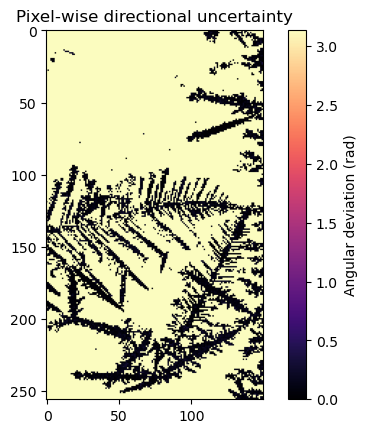

In [33]:
plt.imshow(angular_deviation_map, cmap='magma', vmin=0, vmax=np.pi)
plt.colorbar(label='Angular deviation (rad)')
plt.title('Pixel-wise directional uncertainty')
plt.show()

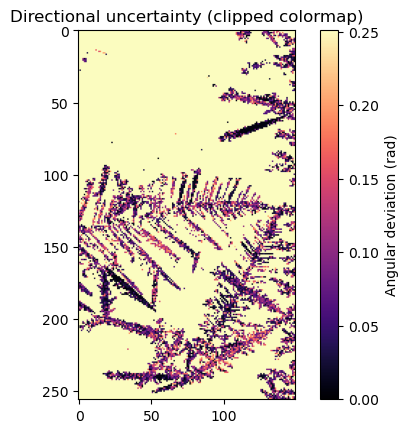

In [34]:
# Exclude max (π) from percentile calculation
valid_devs = angular_deviation_map[angular_deviation_map < np.pi]
vmax_clip = np.percentile(valid_devs, 99)  # e.g., 99th percentile

plt.imshow(angular_deviation_map, cmap='magma', vmin=0, vmax=vmax_clip)
plt.colorbar(label='Angular deviation (rad)')
plt.title('Directional uncertainty (clipped colormap)')
plt.show()

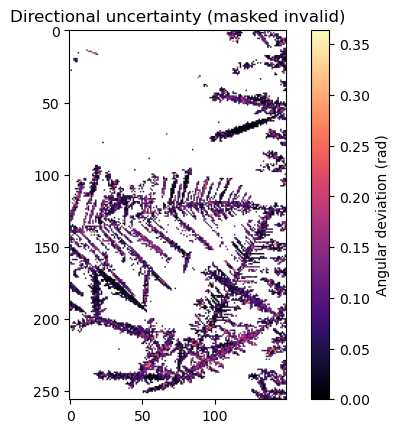

In [36]:
threshold = 1e-12

masked_map = np.ma.masked_where(angular_deviation_map >= (np.pi-threshold), angular_deviation_map)

plt.imshow(masked_map, cmap='magma', vmin=0)
plt.colorbar(label='Angular deviation (rad)')
plt.title('Directional uncertainty (masked invalid)')
plt.show()

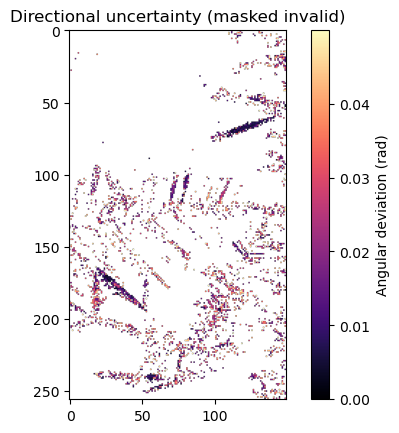

In [37]:
threshold = 1e-12

masked_map = np.ma.masked_where(angular_deviation_map >= (0.05-threshold), angular_deviation_map)

plt.imshow(masked_map, cmap='magma', vmin=0)
plt.colorbar(label='Angular deviation (rad)')
plt.title('Directional uncertainty (masked invalid)')
plt.show()

0.3643657684366833


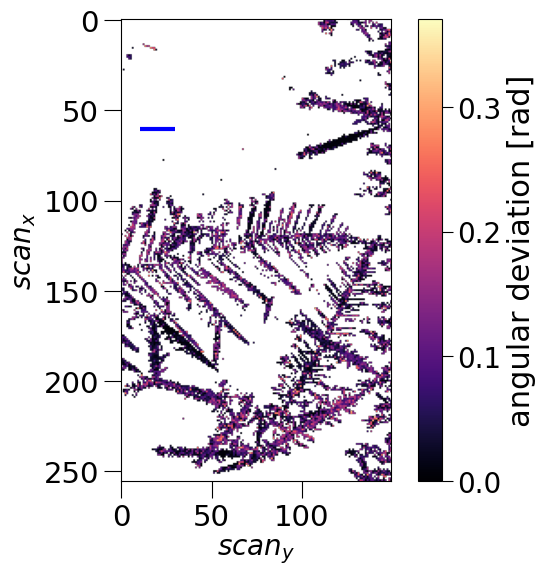

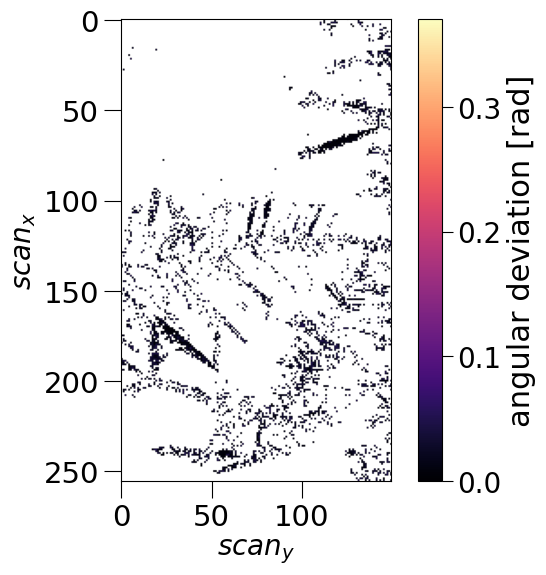

In [8]:
threshold = 1e-12

scan_space_pixel_spacing_nm = 20.2 #[nm]
bar_length_nm = 400 #[nm]
bar_length_pixel = bar_length_nm / scan_space_pixel_spacing_nm

scale_bar_y = 60
scale_bar_x_start = 10
scale_bar_x_end = scale_bar_x_start + bar_length_pixel

masked_map = np.ma.masked_where(angular_deviation_map >= (np.pi-threshold), angular_deviation_map)
print(np.max(masked_map))

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(masked_map, cmap='magma', vmin=0, vmax = 0.37)
cbar = fig.colorbar(im, ax=ax, label='angular deviation [rad]')
# ax.set_title('highly correlated domain', fontsize=12, pad = 15)
cbar.ax.tick_params(labelsize=20,length=8, width=0.8)  # Set tick label font size
cbar.set_ticks([0.0, 0.1, 0.2, 0.30]) 
cbar.set_label('angular deviation [rad]', fontsize=22)  # set label font size
ax.plot([scale_bar_x_start, scale_bar_x_end],[scale_bar_y, scale_bar_y], color = "#0000ff", lw=3, solid_capstyle="butt")
ax.set_xlabel(r"$scan_{y}$", fontsize = 20)
ax.set_ylabel(r"$scan_{x}$", fontsize = 20)
ax.set_yticks([0, 50, 100, 150, 200, 250])
ax.set_xticks([0, 50, 100])
ax.tick_params(axis='both', direction='out', length=12, width=0.8, color='k', labelsize=21)
fig.savefig(script_path + 'angular_deviations_symmetryReducedZ_from_transformerPrediction.pdf', bbox_inches='tight', dpi=300)
plt.show()

small_deviation_masked = np.ma.masked_where(masked_map > 0.052, masked_map)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(small_deviation_masked, cmap='magma', vmin=0, vmax = 0.37)
cbar = fig.colorbar(im, ax=ax, label='angular deviation [rad]')
# ax.set_title('highly correlated domain', fontsize=12, pad = 15)
cbar.ax.tick_params(labelsize=20,length=8, width=0.8)  # Set tick label font size
cbar.set_ticks([0.0, 0.1, 0.2, 0.30]) 
cbar.set_label('angular deviation [rad]', fontsize=22)  # set label font size
ax.set_xlabel(r"$scan_{y}$", fontsize = 20)
ax.set_ylabel(r"$scan_{x}$", fontsize = 20)
ax.set_yticks([0, 50, 100, 150, 200, 250])
ax.set_xticks([0, 50, 100])
ax.tick_params(axis='both', direction='out', length=12, width=0.8, color='k', labelsize=21)
fig.savefig(script_path + 'highly_coherent_pixels_angular_deviations_symmetryReducedZ_from_transformerPrediction.pdf', bbox_inches='tight', dpi=300)
plt.show()

Figure X. Directional uncertainty of the predicted zone-axis across the scan positions. For each pixel, the angular deviation between each model’s predicted zone-axis and the mean zone-axis across all six models is shown. Pixels with no assigned orientations are masked and appear white, while colored pixels indicate angular deviations.



**Figure X.** 
(a) Directional uncertainty of the predicted zone-axis across the scan positions. For each pixel, the angular deviation between each model’s predicted zone-axis and the mean zone-axis across all six models is shown. Pixels with no assigned orientations are masked and appear white, while colored pixels indicate angular deviations. (b) Pixels with low directional uncertainty, corresponding to angular deviations below 0.052 radian (3 degree). These regions indicate locations where model predictions are highly consistent.


(a) Directional uncertainty of the predicted zone-axis across the scan positions. For each pixel, the angular deviation between each model’s prediction and the mean across six models is shown. Pixels with no assigned orientations are masked in white, while colored pixels indicate angular deviations. (b) Regions of low directional uncertainty, with angular deviations below 0.052 rad (3°), highlighting areas where model predictions are highly consistent.

